## Setup

In [ ]:
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.ndimage import rotate
from torch import nn
from torch.nn import functional as func
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from edl_losses import EDLLoss, FEDLLoss, GENLoss, edl_inference, fedl_inference

# Constants
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 30

# Data preparation
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256)

### Digit Rotation Plots

We want to plot the uncertainty/accuracy for possible rotation of the digit `1`.

In [2]:
def find_digit(dataset: torch.utils.data.Dataset, digit: int = 1) -> torch.Tensor:
    """Return the first occurrence of `digit` from the dataset as a (1,1,28,28) tensor.

    Arguments:
        dataset (torch.utils.data.Dataset): The dataset to search through.
        digit (int): The digit to find (0-9).

    Returns:
        torch.Tensor: A tensor of shape (1, 1, 28, 28) containing the first occurrence of the specified digit.

    """
    for img, label in dataset:
        if label == digit:
            return img.unsqueeze(0)  # (1, 1, 28, 28)

    msg = f"Digit {digit} not found in dataset."
    raise ValueError(msg)


def rotate_image(img_tensor: torch.Tensor, angle: float) -> torch.Tensor:
    """Rotate a (1, 1, 28, 28) tensor by `angle` degrees.

    Arguments:
        img_tensor (torch.Tensor): A tensor of shape (1, 1, 28, 28) representing the image to rotate.
        angle (float): The angle in degrees to rotate the image. Positive values rotate counter-clockwise.

    Returns:
        torch.Tensor: A tensor of shape (1, 1, 28, 28) containing the rotated image.

    """
    img_np = img_tensor.squeeze().numpy()  # (28, 28)
    rotated = rotate(img_np, angle, reshape=False)  # same shape, fills with 0

    return torch.tensor(rotated, dtype=torch.float32).unsqueeze(0).unsqueeze(0)


digit_img = find_digit(train_data, digit=1)
n_steps = 37  # ~5° increments like the paper
angles = np.linspace(0, 180, n_steps)


def plot_rotation_analysis(
    model: nn.Module,
    inference_fn: Callable,
    true_class: int = 1,
) -> None:
    """Plot the rotation analysis results.

    Arguments:
        model (nn.Module): The trained model to analyze.
        inference_fn (Callable): The inference function to use (e.g., edl_inference).
        true_class (int): The true class index to plot the probability for (default is 1 for digit '1').

    """
    all_probs = np.zeros((n_steps, 10))
    all_uncertainty = np.zeros(n_steps)

    for i, angle in enumerate(angles):
        rotated = rotate_image(digit_img, angle)
        model_results = model(rotated.to(DEVICE))
        if not isinstance(model_results, tuple):
            model_results = (model_results,)
        _, uncertainty, class_probs = inference_fn(*model_results)
        all_probs[i] = class_probs.detach().squeeze().cpu().numpy()
        all_uncertainty[i] = uncertainty.detach().cpu().item()

    p_correct = all_probs[:, true_class]

    plt.figure(figsize=(8, 5))

    plt.plot(angles, p_correct, label="P(correct)", color="black", marker="s", markevery=4, linewidth=1.5)
    plt.plot(
        angles,
        all_uncertainty,
        label="uncertainty",
        color="green",
        marker="x",
        markevery=4,
        linewidth=1.5,
        linestyle="--",
    )

    plt.title("Rotation Analysis of Digit '1'")
    plt.xlabel("Rotation Angle")
    plt.ylabel("Probability / Uncertainty")
    plt.xlim(0, 180)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Evaluation function

In [3]:
def evaluate_model(model: nn.Module, inference_fn: Callable) -> None:
    """Evaluate the model on the test set and print accuracy and uncertainty statistics.

    Arguments:
        model (nn.Module): The trained model to evaluate.
        inference_fn (Callable): The inference function to use (e.g., edl_inference).

    """
    model.eval()

    correct = total = 0
    mean_uncertainty_correct = mean_uncertainty_wrong = 0
    n_correct = n_wrong = 0

    with torch.no_grad():
        for x, y in test_loader:
            model_results = model(x.to(DEVICE))
            if not isinstance(model_results, tuple):
                model_results = (model_results,)
            pred, uncertainty, _ = inference_fn(*model_results)

            mask_correct = pred == y.to(DEVICE)
            mask_wrong = ~mask_correct

            correct += mask_correct.sum().item()
            total += y.to(DEVICE).size(0)
            mean_uncertainty_correct += uncertainty[mask_correct].sum().item()
            mean_uncertainty_wrong += uncertainty[mask_wrong].sum().item()
            n_correct += mask_correct.sum().item()
            n_wrong += mask_wrong.sum().item()

    print(f"\nTest accuracy: {correct / total:.4f}")
    print(f"Mean uncertainty — correct: {mean_uncertainty_correct / max(n_correct, 1):.4f}")
    print(f"Mean uncertainty — wrong: {mean_uncertainty_wrong / max(n_wrong, 1):.4f}")

### LeNet Model

We will evaluate all EDL loss functions using the same LeNet architecture

In [4]:
class LeNet(nn.Module):
    """Standard LeNet-5 for MNIST. Returns flat features before classifier."""

    def __init__(self) -> None:
        """Initialize the LeNet architecture."""
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 20, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(20, 50, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(nn.Linear(800, 500), nn.ReLU())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the LeNet architecture.

        Arguments:
            x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

        Returns:
            Tensor of shape (batch_size, 500) representing the features before the classifier.

        """
        return self.fc(self.features(x).flatten(1))

## EDL

In [5]:
class EDLModel(nn.Module):
    """EDL classifier with LeNet backbone. Outputs raw logits for evidence (no softmax)."""

    def __init__(self, num_classes: int = 10) -> None:
        """Initialize the EDL model architecture."""
        super().__init__()
        self.backbone = LeNet()
        self.classifier = nn.Linear(500, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the EDL model.

        Arguments:
            x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

        Returns:
            Tensor of shape (batch_size, num_classes) representing raw logits for evidence.

        """
        return self.classifier(self.backbone(x))  # raw logits, NO softmax

In [6]:
model = EDLModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        loss = EDLLoss()(model(x.to(DEVICE)), y.to(DEVICE), epoch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch}/{NUM_EPOCHS} loss={total_loss / len(train_loader):.4f}")

Epoch 1/30 loss=0.5172
Epoch 2/30 loss=0.3954
Epoch 3/30 loss=0.3781
Epoch 4/30 loss=0.3729
Epoch 5/30 loss=0.3656
Epoch 6/30 loss=0.3635
Epoch 7/30 loss=0.3602
Epoch 8/30 loss=0.3563
Epoch 9/30 loss=0.3605
Epoch 10/30 loss=0.3550
Epoch 11/30 loss=0.3463
Epoch 12/30 loss=0.3453
Epoch 13/30 loss=0.3405
Epoch 14/30 loss=0.3397
Epoch 15/30 loss=0.3371
Epoch 16/30 loss=0.3306
Epoch 17/30 loss=0.3341
Epoch 18/30 loss=0.3286
Epoch 19/30 loss=0.3300
Epoch 20/30 loss=0.3267
Epoch 21/30 loss=0.3283
Epoch 22/30 loss=0.3243
Epoch 23/30 loss=0.3272
Epoch 24/30 loss=0.3236
Epoch 25/30 loss=0.3213
Epoch 26/30 loss=0.3211
Epoch 27/30 loss=0.3194
Epoch 28/30 loss=0.3208
Epoch 29/30 loss=0.3176
Epoch 30/30 loss=0.3203



Test accuracy: 0.6835
Mean uncertainty — correct: 0.0622
Mean uncertainty — wrong: 0.9916


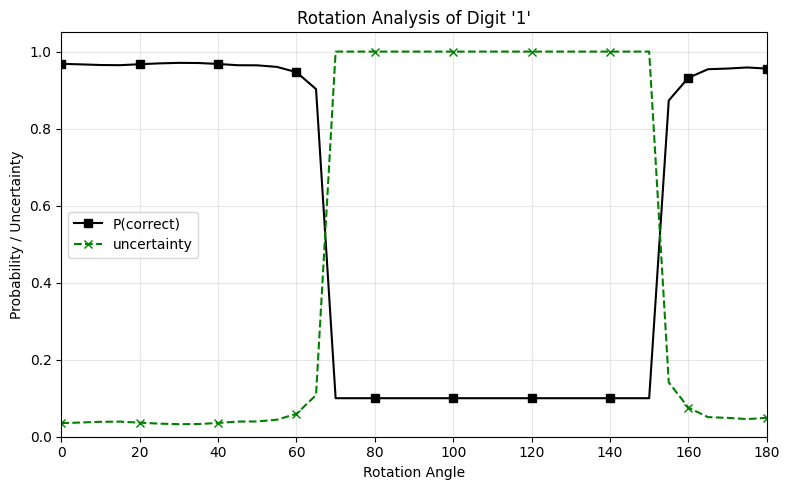

In [7]:
evaluate_model(model, edl_inference)
plot_rotation_analysis(model, edl_inference)

## GEN

In [8]:
class GENModel(nn.Module):
    """Same classifier as EDL. OOD samples are generated externally during training."""

    def __init__(self, num_classes: int = 10) -> None:
        """Initialize the GEN model architecture."""
        super().__init__()
        self.backbone = LeNet()
        self.classifier = nn.Linear(500, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the GEN model.

        Arguments:
            x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

        Returns:
            Tensor of shape (batch_size, num_classes) representing raw logits for classification.

        """
        return self.classifier(self.backbone(x))

In [9]:
def _make_ood_samples(x: torch.Tensor) -> torch.Tensor:
    """Add Gaussian noise to push samples off-distribution.

    In production this would be the VAE+GAN generator from the paper.

    Arguments:
        x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

    Returns:
        Tensor of the same shape as x, but with added noise to simulate OOD samples.

    """
    return torch.clamp(x + 0.3 * torch.randn_like(x), 0, 1)


model = GENModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x_ood = _make_ood_samples(x.to(DEVICE))
        optimizer.zero_grad()
        loss = GENLoss()(model(x.to(DEVICE)), model(x_ood), y.to(DEVICE))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}/{NUM_EPOCHS} loss={total_loss / len(train_loader):.4f}")

Epoch 1/30 loss=0.4847
Epoch 2/30 loss=0.1220
Epoch 3/30 loss=0.0854
Epoch 4/30 loss=0.0669
Epoch 5/30 loss=0.0531
Epoch 6/30 loss=0.0446
Epoch 7/30 loss=0.0372
Epoch 8/30 loss=0.0303
Epoch 9/30 loss=0.0240
Epoch 10/30 loss=0.0206
Epoch 11/30 loss=0.0167
Epoch 12/30 loss=0.0155
Epoch 13/30 loss=0.0116
Epoch 14/30 loss=0.0136
Epoch 15/30 loss=0.0096
Epoch 16/30 loss=0.0099
Epoch 17/30 loss=0.0172
Epoch 18/30 loss=0.0070
Epoch 19/30 loss=0.0062
Epoch 20/30 loss=0.0061
Epoch 21/30 loss=0.0115
Epoch 22/30 loss=0.0040
Epoch 23/30 loss=0.0022
Epoch 24/30 loss=0.0030
Epoch 25/30 loss=0.0048
Epoch 26/30 loss=0.0020
Epoch 27/30 loss=0.0169
Epoch 28/30 loss=0.0098
Epoch 29/30 loss=0.0105
Epoch 30/30 loss=0.0030



Test accuracy: 0.9930
Mean uncertainty — correct: 0.4221
Mean uncertainty — wrong: 0.7668


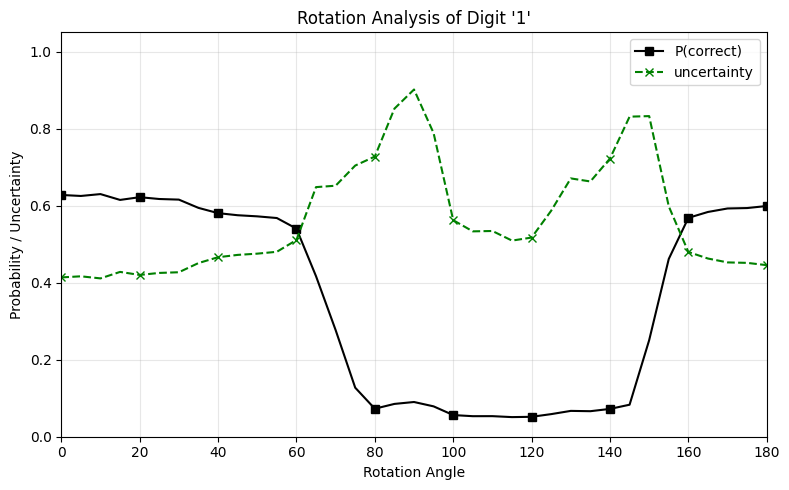

In [10]:
evaluate_model(model, edl_inference)
plot_rotation_analysis(model, edl_inference)

## F-EDL

In [11]:
class FEDLModel(nn.Module):
    """F-EDL classifier with LeNet backbone. Outputs separate heads for alpha, p, and tau."""

    def __init__(self, num_classes: int = 10, mlp_hidden: int = 64) -> None:
        """Initialize the F-EDL model architecture."""
        super().__init__()
        self.backbone = LeNet()

        # Three separate heads
        self.head_alpha = nn.Linear(500, num_classes)  # evidence
        self.head_p = nn.Linear(500, num_classes)  # allocation probs
        self.head_tau = nn.Sequential(  # dispersion
            nn.Linear(500, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, 1),
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Forward pass through the F-EDL model.

        Arguments:
            x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

        Returns:
            alpha: Tensor of shape (batch_size, num_classes) representing evidence for each class.
            p: Tensor of shape (batch_size, num_classes) representing allocation probabilities.
            tau: Tensor of shape (batch_size,) representing dispersion.

        """
        z = self.backbone(x)
        alpha = torch.exp(self.head_alpha(z))
        p = torch.softmax(self.head_p(z), dim=-1)
        tau = func.softplus(self.head_tau(z)).squeeze(-1)
        return alpha, p, tau

In [12]:
model = FEDLModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        alpha, p, tau = model(x.to(DEVICE))
        alpha = torch.clamp(alpha, 1e-6, 1e4)
        tau = torch.clamp(tau, 1e-6, 1e4)
        loss = FEDLLoss()(alpha, p, tau, y.to(DEVICE))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}/{NUM_EPOCHS} loss={total_loss / len(train_loader):.4f}")

Epoch 1/30 loss=0.3025
Epoch 2/30 loss=0.0713
Epoch 3/30 loss=0.0519
Epoch 4/30 loss=0.0383
Epoch 5/30 loss=0.0306
Epoch 6/30 loss=0.0266
Epoch 7/30 loss=0.0222
Epoch 8/30 loss=0.0189
Epoch 9/30 loss=0.0157
Epoch 10/30 loss=0.0146
Epoch 11/30 loss=0.0128
Epoch 12/30 loss=0.0118
Epoch 13/30 loss=0.0091
Epoch 14/30 loss=0.0096
Epoch 15/30 loss=0.0092
Epoch 16/30 loss=0.0081
Epoch 17/30 loss=0.0084
Epoch 18/30 loss=0.0066
Epoch 19/30 loss=0.0059
Epoch 20/30 loss=0.0064
Epoch 21/30 loss=0.0068
Epoch 22/30 loss=0.0084
Epoch 23/30 loss=0.0056
Epoch 24/30 loss=0.0054
Epoch 25/30 loss=0.0058
Epoch 26/30 loss=0.0040
Epoch 27/30 loss=0.0042
Epoch 28/30 loss=0.0052
Epoch 29/30 loss=0.0049
Epoch 30/30 loss=0.0067



Test accuracy: 0.9923
Mean uncertainty — correct: 0.0034
Mean uncertainty — wrong: 0.2630


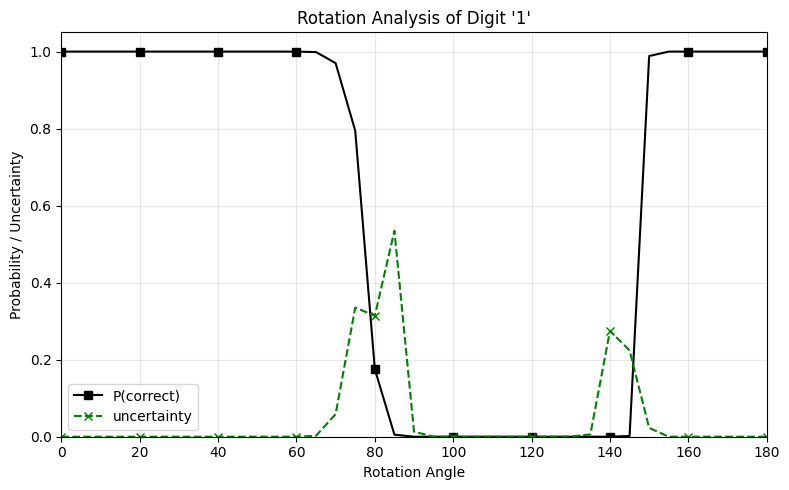

In [13]:
evaluate_model(model, fedl_inference)
plot_rotation_analysis(model, fedl_inference)